# Setup

In [24]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import tensorflow as tf
from geexhp import modelfuncs as mf
from geexhp import datavis as dvis

dvis.configure_matplotlib()

# Write each filtered DataFrame to TFRecord files

In [4]:
mf.tfrecord_conversion.create_tfrecords(
    root_folder="../parallel", save_root="../data/tfrecords"
)

🌍 Progress: |██████████████████████████████| 100% (1188/1188 files) ⏳ [1:39:55 elapsed]


In [5]:
mf.datasetup.concatenate_all_tfrecords(
    root_folder="../data/tfrecords",
    output_tfrecord_file="../data/all_samples.tfrecord",
)

Concatenated TFRecord file saved to '../data/all_samples.tfrecord'


# SNR MIN-MAX vs SNR PCTL

In [27]:
tfrecord_file = "../data/all_samples.tfrecord"

In [5]:
feature_description = {}
telescopes = ["B", "SS"]
bands = ["UV", "Vis", "NIR"]
bases = [f"{tel}-{band}" for tel in telescopes for band in bands]

for base in bases:
    feature_description[f"SNR_FEATURE_{base}"] = tf.io.FixedLenFeature([], tf.float32)
    feature_description[f"SNR_FEATURE_PCTL_{base}"] = tf.io.FixedLenFeature(
        [], tf.float32
    )

orig_keys = [f"SNR_FEATURE_{base}" for base in bases]
pctl_keys = [f"SNR_FEATURE_PCTL_{base}" for base in bases]


def _parse_fn(example_proto):
    parsed = tf.io.parse_single_example(example_proto, feature_description)
    orig = tf.stack([parsed[k] for k in orig_keys], axis=0)  # (6,)
    pctl = tf.stack([parsed[k] for k in pctl_keys], axis=0)  # (6,)
    return orig, pctl


batch_size = 4096
max_batches = None

ds = (
    tf.data.TFRecordDataset(tfrecord_file, num_parallel_reads=tf.data.AUTOTUNE)
    .map(_parse_fn, num_parallel_calls=tf.data.AUTOTUNE, deterministic=False)
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

if max_batches is not None:
    ds = ds.take(max_batches)

orig_batches = []
pctl_batches = []

for orig_batch, pctl_batch in ds:
    orig_batches.append(orig_batch.numpy())  # (B, 6)
    pctl_batches.append(pctl_batch.numpy())  # (B, 6)

if orig_batches:
    orig_all = np.concatenate(orig_batches, axis=0)
    pctl_all = np.concatenate(pctl_batches, axis=0)
else:
    orig_all = np.empty((0, len(bases)), dtype=np.float32)
    pctl_all = np.empty((0, len(bases)), dtype=np.float32)

snr_data = {
    base: {"orig": orig_all[:, i], "pctl": pctl_all[:, i]}
    for i, base in enumerate(bases)
}

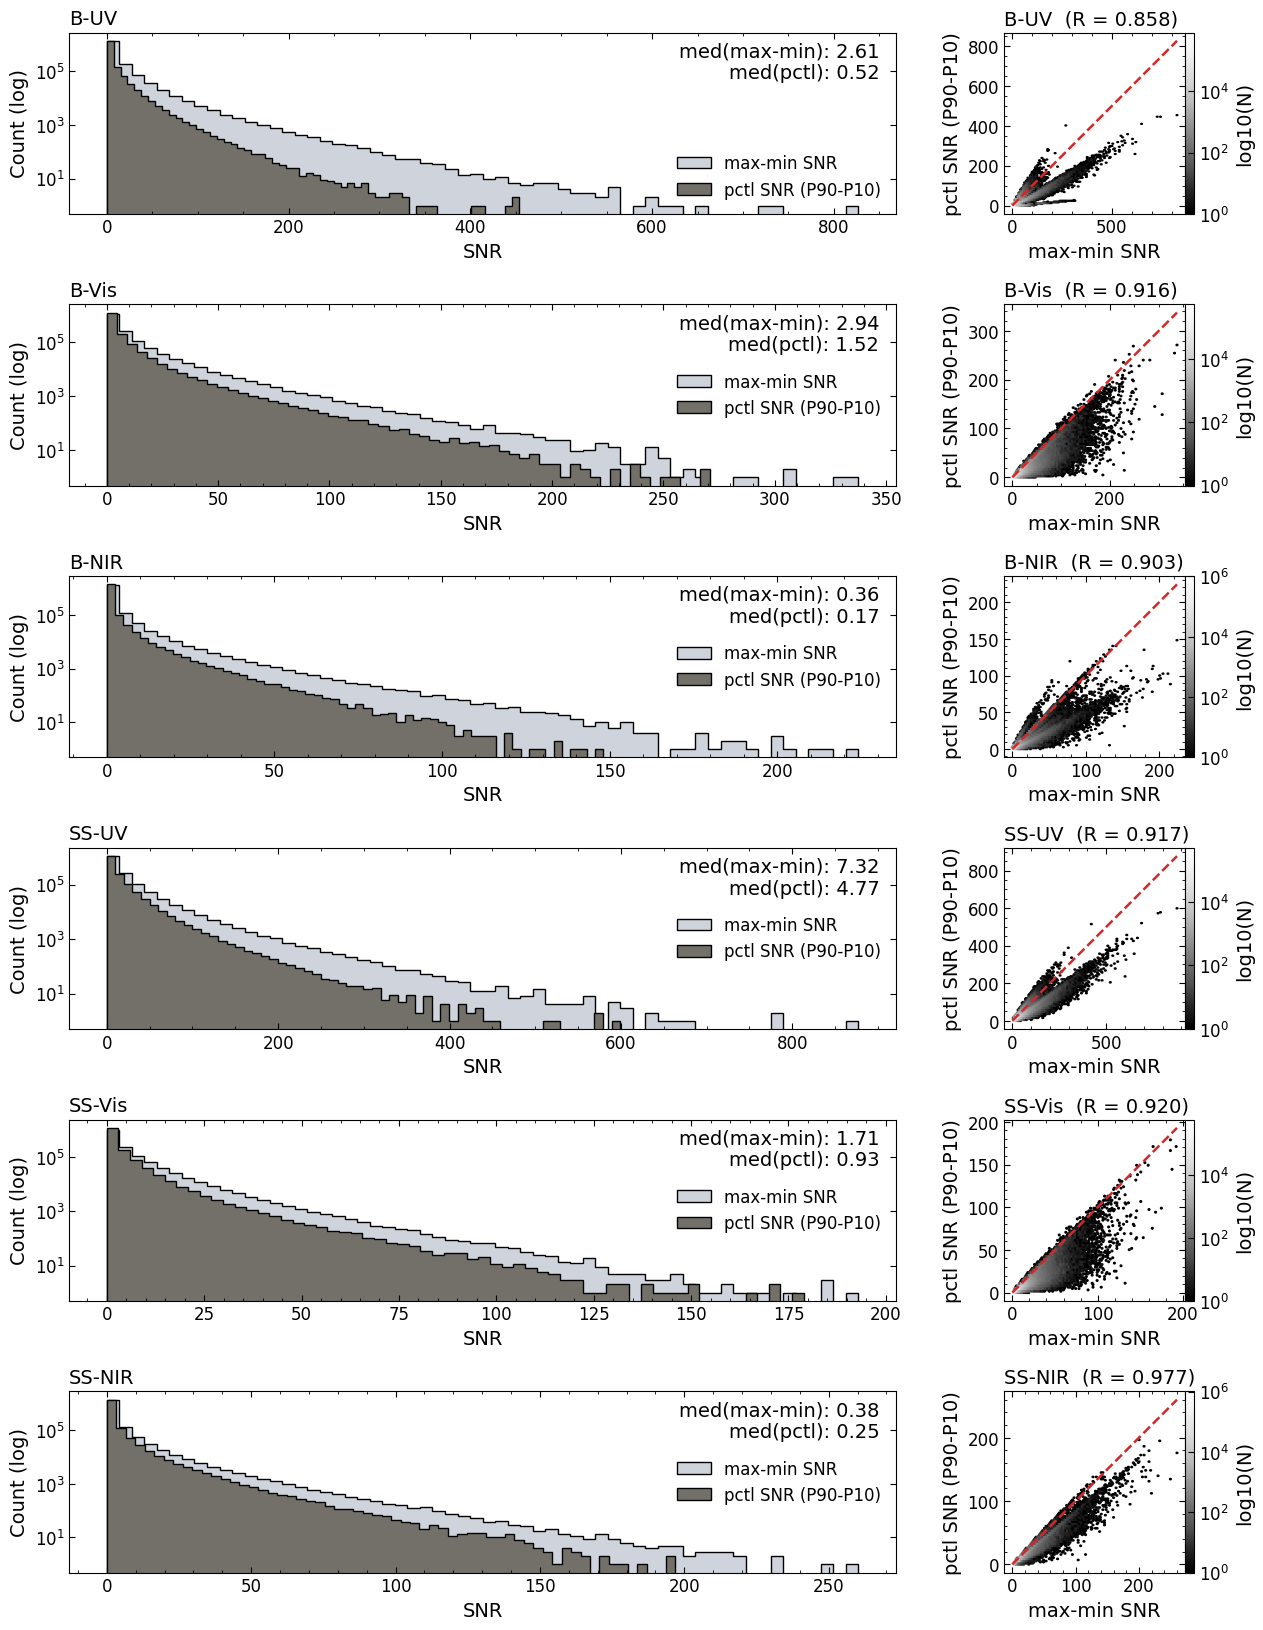

In [ ]:
bases_plot = ["B-UV", "B-Vis", "B-NIR", "SS-UV", "SS-Vis", "SS-NIR"]
n_rows, n_cols = len(bases_plot), 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 20))

c_orig = "#ced3dc"
c_pctl = "#73706a"
c_diag = "tab:red"

for i, base in enumerate(bases_plot):
    x = snr_data[base]["orig"]
    y = snr_data[base]["pctl"]

    ax_hist = axes[i, 0]
    ax_rel = axes[i, 1]

    if x.size == 0 or y.size == 0:
        ax_hist.set_title(f"{base} (sem dados)")
        ax_rel.set_title(f"{base} (sem dados)")
        continue

    med_x = np.median(x)
    med_y = np.median(y)
    corr = np.corrcoef(x, y)[0, 1]

    ax_hist.hist(
        x,
        bins=60,
        color=c_orig,
        label="max-min SNR",
        edgecolor="k",
        histtype="stepfilled",
    )
    ax_hist.hist(
        y,
        bins=60,
        color=c_pctl,
        label="pctl SNR (P90-P10)",
        edgecolor="k",
        histtype="stepfilled",
    )
    ax_hist.set_yscale("log")
    ax_hist.set_xlabel("SNR")
    ax_hist.set_ylabel("Count (log)")
    ax_hist.set_title(f"{base}", loc="left")
    ax_hist.legend()

    ax_hist.text(
        0.98,
        0.95,
        f"med(max-min): {med_x:.2f}\nmed(pctl): {med_y:.2f}",
        transform=ax_hist.transAxes,
        ha="right",
        va="top",
    )

    hb = ax_rel.hexbin(x, y, gridsize=100, mincnt=1, bins="log", cmap="Grays_r")
    lim_min = float(min(x.min(), y.min()))
    lim_max = float(max(x.max(), y.max()))
    ax_rel.plot([lim_min, lim_max], [lim_min, lim_max], ls="--", lw=1.8, color=c_diag)
    ax_rel.set_aspect("equal", adjustable="box")

    ax_rel.set_xlabel("max-min SNR")
    ax_rel.set_ylabel("pctl SNR (P90-P10)")
    ax_rel.set_title(f"{base}  (R = {corr:.3f})", loc="left")
    cb = fig.colorbar(hb, ax=ax_rel, pad=0)
    cb.set_label("log10(N)")

plt.subplots_adjust(hspace=0.5, wspace=-0.5)
plt.show()

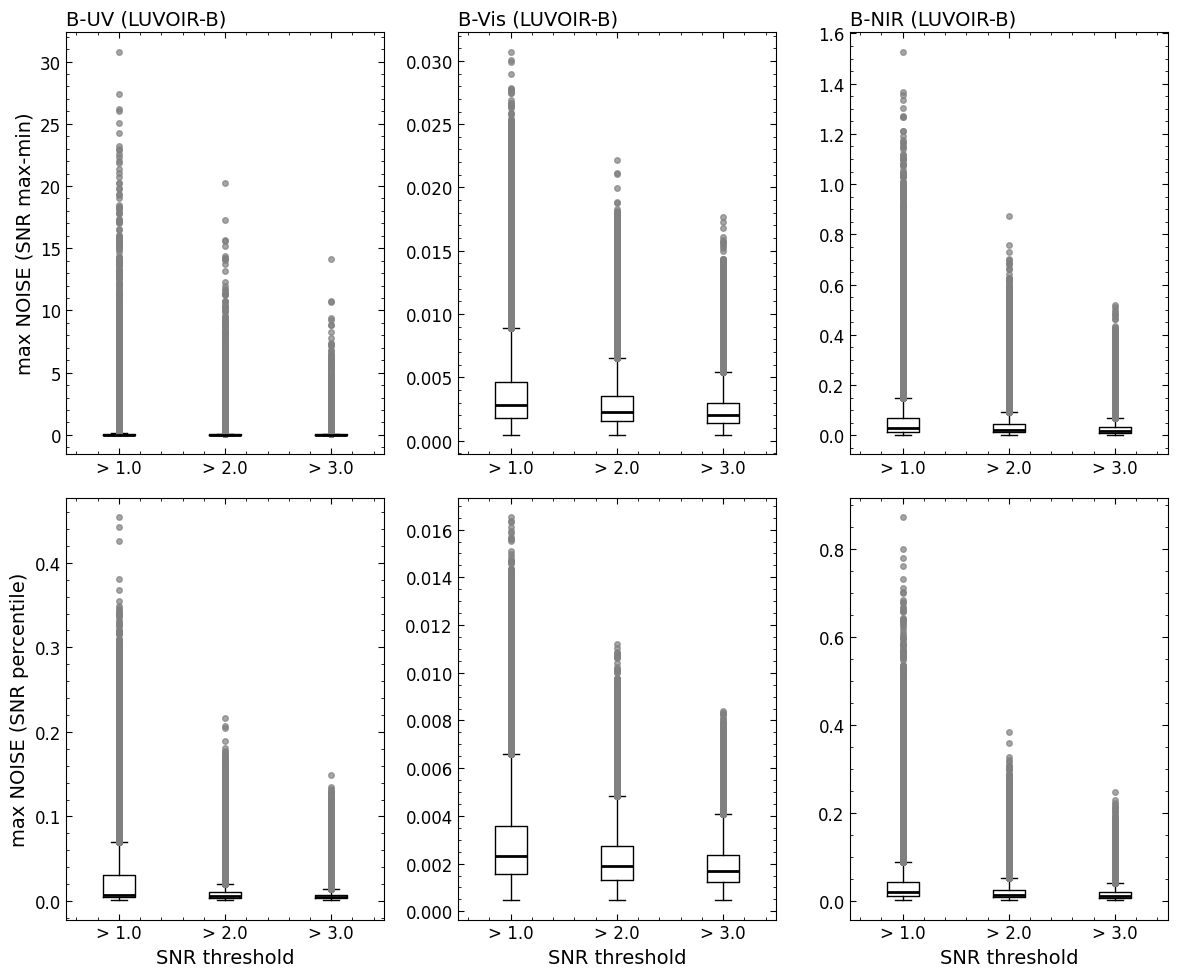

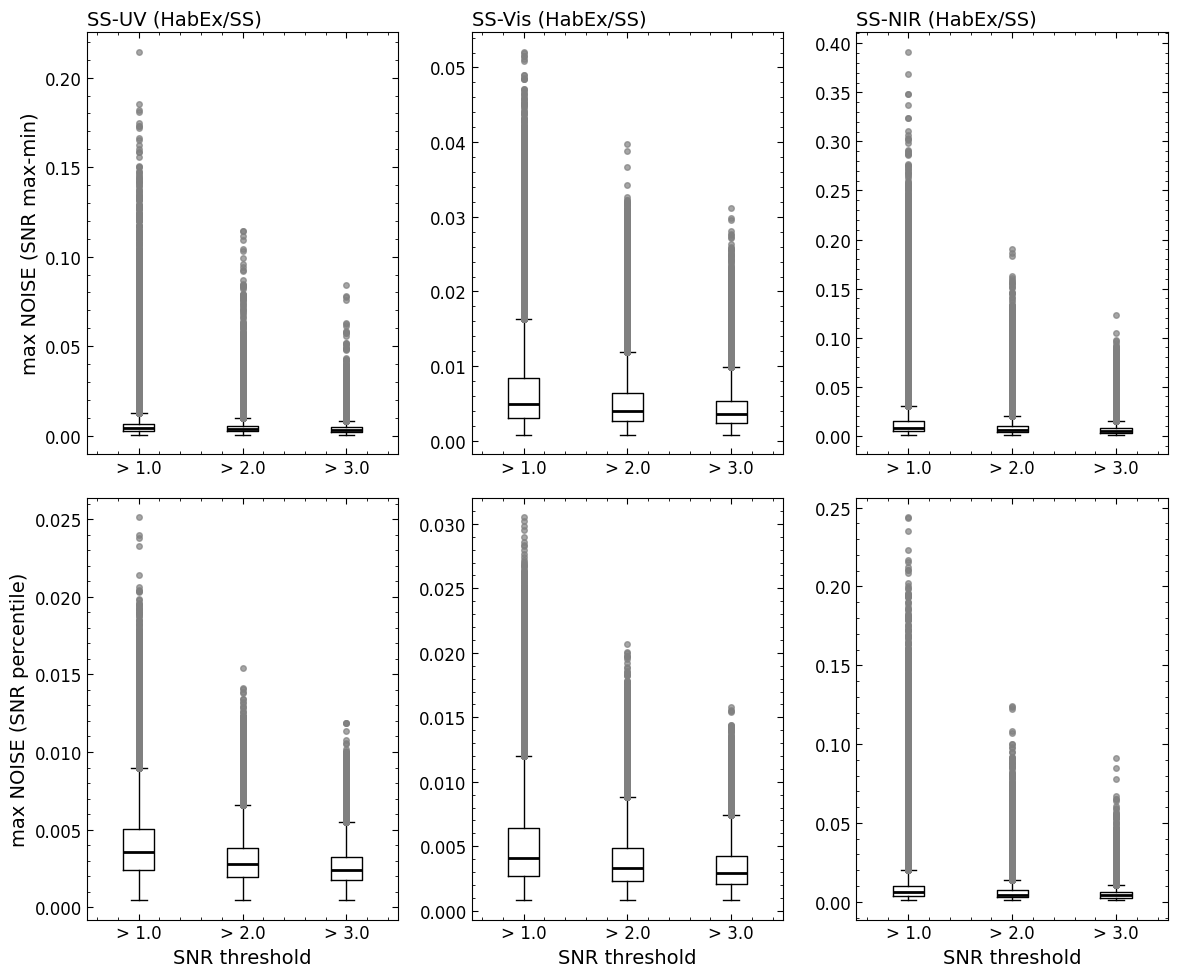

In [22]:
telescopes = ["B", "SS"]
bands = ["UV", "Vis", "NIR"]
bases = [f"{tel}-{band}" for tel in telescopes for band in bands]
thresholds = [1.0, 2.0, 3.0]

feature_description = {
    **{f"SNR_FEATURE_{b}": tf.io.FixedLenFeature([], tf.float32) for b in bases},
    **{f"SNR_FEATURE_PCTL_{b}": tf.io.FixedLenFeature([], tf.float32) for b in bases},
    **{f"NOISE_{b}": tf.io.VarLenFeature(tf.float32) for b in bases},
}


def _parse_fn(example_proto):
    parsed = tf.io.parse_single_example(example_proto, feature_description)

    snr_orig = tf.stack([parsed[f"SNR_FEATURE_{b}"] for b in bases], axis=0)  # (6,)
    snr_pctl = tf.stack(
        [parsed[f"SNR_FEATURE_PCTL_{b}"] for b in bases], axis=0
    )  # (6,)

    noise_max = tf.stack(
        [tf.reduce_max(tf.sparse.to_dense(parsed[f"NOISE_{b}"])) for b in bases],
        axis=0,
    )

    return snr_orig, snr_pctl, noise_max


max_batches = None
batch_size = 4096

ds = (
    tf.data.TFRecordDataset(tfrecord_file, num_parallel_reads=tf.data.AUTOTUNE)
    .map(_parse_fn, num_parallel_calls=tf.data.AUTOTUNE, deterministic=False)
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)
if max_batches is not None:
    ds = ds.take(max_batches)

snr_orig_batches, snr_pctl_batches, noise_max_batches = [], [], []
for snr_orig_b, snr_pctl_b, noise_max_b in ds:
    snr_orig_batches.append(snr_orig_b.numpy())
    snr_pctl_batches.append(snr_pctl_b.numpy())
    noise_max_batches.append(noise_max_b.numpy())

snr_orig_mat = (
    np.concatenate(snr_orig_batches, axis=0)
    if snr_orig_batches
    else np.empty((0, len(bases)))
)
snr_pctl_mat = (
    np.concatenate(snr_pctl_batches, axis=0)
    if snr_pctl_batches
    else np.empty((0, len(bases)))
)
noise_max_mat = (
    np.concatenate(noise_max_batches, axis=0)
    if noise_max_batches
    else np.empty((0, len(bases)))
)

mask_finite = (
    np.isfinite(snr_orig_mat).all(axis=1)
    & np.isfinite(snr_pctl_mat).all(axis=1)
    & np.isfinite(noise_max_mat).all(axis=1)
)
snr_orig_mat = snr_orig_mat[mask_finite]
snr_pctl_mat = snr_pctl_mat[mask_finite]
noise_max_mat = noise_max_mat[mask_finite]

idx_map = {base: i for i, base in enumerate(bases)}


def select_noise_groups(snr_mat, noise_col, thr_list):
    groups = []
    for thr in thr_list:
        keep = (snr_mat > thr).all(axis=1)
        vals = noise_col[keep]
        groups.append(vals if vals.size else np.array([np.nan]))
    return groups


row_specs = [
    ("max NOISE (SNR max-min)", snr_orig_mat),
    ("max NOISE (SNR percentile)", snr_pctl_mat),
]

for tel in telescopes:
    fig, axes = plt.subplots(2, 3, figsize=(12, 10))
    tel_label = {"B": "LUVOIR-B", "SS": "HabEx/SS"}

    for j, band in enumerate(bands):
        base = f"{tel}-{band}"
        idx = idx_map[base]
        noise_col = noise_max_mat[:, idx]

        for row, (ylabel, snr_mat) in enumerate(row_specs):
            ax = axes[row, j]
            data = select_noise_groups(snr_mat, noise_col, thresholds)
            ax.boxplot(
                data,
                tick_labels=[f"> {t}" for t in thresholds],
                flierprops=dict(
                    marker="o",
                    markerfacecolor="gray",
                    markeredgecolor="gray",
                    markersize=4,
                    alpha=0.7,
                ),
                medianprops=dict(color="black", linewidth=2),
            )
            if row == 0:
                ax.set_title(f"{base} ({tel_label[tel]})", loc="left")
            if j == 0:
                ax.set_ylabel(ylabel)
            if row == 1:
                ax.set_xlabel("SNR threshold")

    plt.tight_layout()
    plt.show()

# Train/Validation/Test split (SNR PCTL > 3)

In [6]:
telescopes = ["B", "SS"]
bands = ["UV", "Vis", "NIR"]
bases = [f"{tel}-{band}" for tel in telescopes for band in bands]

feature_description = {
    "Earth_type": tf.io.FixedLenFeature([], tf.string),
}
for base in bases:
    feature_description[f"SNR_FEATURE_PCTL_{base}"] = tf.io.FixedLenFeature(
        [], tf.float32
    )


def parse_example(serialized):
    parsed = tf.io.parse_single_example(serialized, feature_description)
    earth = parsed["Earth_type"].numpy().decode("utf-8")
    snr_vals = np.array(
        [parsed[f"SNR_FEATURE_PCTL_{base}"].numpy() for base in bases],
        dtype=np.float32,
    )
    return earth, snr_vals


raw_ds = tf.data.TFRecordDataset(tfrecord_file)

examples_by_era = defaultdict(list)

N_total = 0
N_keep = 0

for raw in raw_ds:
    serialized = raw.numpy()
    N_total += 1

    earth, snr_vals = parse_example(serialized)

    if np.isfinite(snr_vals).all() and (snr_vals > 3.0).all():
        examples_by_era[earth].append(serialized)
        N_keep += 1

print(f"Total examples read     : {N_total}")
print(f"Examples with SNR_pctl > 3 in all bands: {N_keep}")

for era, ex_list in examples_by_era.items():
    print(f"  {era}: {len(ex_list)} examples")

rng = np.random.default_rng(42)

train_examples = []
val_examples = []
test_examples = []

for era, ex_list in examples_by_era.items():
    ex_array = np.array(ex_list, dtype=object)
    rng.shuffle(ex_array)

    n = len(ex_array)
    n_train = int(0.8 * n)
    n_val = int(0.1 * n)
    n_test = n - n_train - n_val

    train_era = ex_array[:n_train]
    val_era = ex_array[n_train : n_train + n_val]
    test_era = ex_array[n_train + n_val :]

    train_examples.extend(train_era.tolist())
    val_examples.extend(val_era.tolist())
    test_examples.extend(test_era.tolist())

    print(f"\nEra = {era}")
    print(f"  total   : {n}")
    print(f"  train   : {len(train_era)}")
    print(f"  val     : {len(val_era)}")
    print(f"  test    : {len(test_era)}")

rng.shuffle(train_examples)
rng.shuffle(val_examples)
rng.shuffle(test_examples)

print("\nFinal split sizes:")
print(f"  train: {len(train_examples)}")
print(f"  val  : {len(val_examples)}")
print(f"  test : {len(test_examples)}")

train_path = os.path.join("../data", "train.tfrecord")
val_path = os.path.join("../data", "val.tfrecord")
test_path = os.path.join("../data", "test.tfrecord")


def write_tfrecord(path, serialized_list):
    with tf.io.TFRecordWriter(path) as w:
        for ex in serialized_list:
            w.write(ex)


write_tfrecord(train_path, train_examples)
write_tfrecord(val_path, val_examples)
write_tfrecord(test_path, test_examples)

print("\nSaved TFRecords:")
print("  ", train_path)
print("  ", val_path)
print("  ", test_path)

Total examples read     : 1618088
Examples with SNR_pctl > 3 in all bands: 108246
  archean: 34120 examples
  proterozoic: 38754 examples
  modern: 35372 examples

Era = archean
  total   : 34120
  train   : 27296
  val     : 3412
  test    : 3412

Era = proterozoic
  total   : 38754
  train   : 31003
  val     : 3875
  test    : 3876

Era = modern
  total   : 35372
  train   : 28297
  val     : 3537
  test    : 3538

Final split sizes:
  train: 86596
  val  : 10824
  test : 10826

Saved TFRecords:
   ../data/train.tfrecord
   ../data/val.tfrecord
   ../data/test.tfrecord


In [ ]:
def merge_tfrecords(inputs, output, input_compression=None, output_compression=None):
    ds = tf.data.TFRecordDataset(
        inputs, compression_type=input_compression, num_parallel_reads=tf.data.AUTOTUNE
    )

    options = None
    if output_compression:
        options = tf.io.TFRecordOptions(compression_type=output_compression)

    writer = tf.io.TFRecordWriter(output, options=options)
    for raw in ds:
        writer.write(raw.numpy())
    writer.close()


merge_tfrecords(
    inputs=["../data/train.tfrecord", "../data/val.tfrecord", "../data/test.tfrecord"],
    output="../data/all.tfrecord",
    input_compression=None,
    output_compression=None,
)

2026-01-26 09:59:12.278930: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [33]:
def count_records(path, compression=None):
    return sum(1 for _ in tf.data.TFRecordDataset(path, compression_type=compression))


print("train:", count_records("../data/train.tfrecord"))
print("val:", count_records("../data/val.tfrecord"))
print("test:", count_records("../data/test.tfrecord"))
print("all:", count_records("../data/all.tfrecord"))

train: 86596
val: 10824
test: 10826
all: 108246


# Reading TFRecord file

In [26]:
# Parsing function.
def parse_example(example_proto, feature_description):
    # Parse the example.
    parsed_features = tf.io.parse_single_example(example_proto, feature_description)

    # Convert SparseTensors to DenseTensors.
    #   This is necessary because we loaded features with variable length.
    #   Although the parsed files have the desired data, they have other things
    #   (indices, values and dense_shape). Neural networks must work with values
    #   in a more direct way.
    dense_features = {
        key: (
            tf.sparse.to_dense(value, default_value=0.0)
            if isinstance(value, tf.SparseTensor)
            else value
        )
        for key, value in parsed_features.items()
    }

    return dense_features

In [28]:
tfrecord_file = "../data/all.tfrecord"

In [32]:
# Sum of all samples simulated
(
    500
    + 10000
    + 15000
    + 20000
    + 2500
    + 2500
    + 10000
    + 7500
    + 25000
    + 5000
    + 5000
    + 10000
    + 40000
    + 50000
    + 10000
    + 10000
    + 25000
    + 60000
    + 70000
    + 15000
    + 10000
    + 50000
    + 75000
    + 75000
    + 400000
    + 50000
    + 80000
    + 10000
    + 35000
    + 5000
    + 30000
    + 20000
    + 25000
) * 3

3774000

In [35]:
# Porcentage of the final dataset
(108246 / 3774000) * 100

2.868203497615262

## Read TFRecords with unknown feature_description

In [36]:
# Read the TFRecord.
raw_dataset = tf.data.TFRecordDataset(tfrecord_file)

In [37]:
# Inspect and parse a single record to infer feature names.
for raw_record in raw_dataset.take(1):
    example = tf.train.Example()
    example.ParseFromString(raw_record.numpy())
    print(example)  # Inspect the parsed example
    break

features {
  feature {
    key: "SNR_SS-Vis"
    value {
      float_list {
        value: 34.9998169
        value: 34.6958771
        value: 33.8437767
        value: 32.0083733
        value: 31.1716957
        value: 31.3299809
        value: 29.6474133
        value: 27.3013878
        value: 22.7673931
        value: 22.5022221
        value: 24.147068
        value: 25.2824
        value: 24.7372913
        value: 23.8455219
        value: 22.6363583
        value: 19.858881
        value: 17.3198795
        value: 16.800848
        value: 16.9907513
        value: 16.1148586
        value: 15.1234379
        value: 13.7463856
        value: 11.7700176
        value: 10.0002575
        value: 9.1800108
        value: 9.17006588
        value: 8.66657448
        value: 7.94539785
        value: 7.43382883
        value: 6.93567657
        value: 6.27791834
        value: 5.43368816
        value: 4.68881559
        value: 4.0372262
        value: 3.47523856
        value: 3.25807

In [38]:
# Dynamically build an infered_feature_description
# Parse the inspected "example" to infer the feature description
infered_feature_description = {}
for key, value in example.features.feature.items():
    # Determine the type of the feature
    if value.HasField("bytes_list"):
        if len(value.bytes_list.value) > 1:  # Check for multiple values
            infered_feature_description[key] = tf.io.VarLenFeature(tf.string)
        else:
            infered_feature_description[key] = tf.io.FixedLenFeature([], tf.string)
    elif value.HasField("float_list"):
        if len(value.float_list.value) > 1:  # Check for multiple values
            infered_feature_description[key] = tf.io.VarLenFeature(tf.float32)
        else:
            infered_feature_description[key] = tf.io.FixedLenFeature([], tf.float32)
    elif value.HasField("int64_list"):
        if len(value.int64_list.value) > 1:  # Check for multiple values
            infered_feature_description[key] = tf.io.VarLenFeature(tf.int64)
        else:
            infered_feature_description[key] = tf.io.FixedLenFeature([], tf.int64)

In [39]:
infered_feature_description

{'C2H6': FixedLenFeature(shape=[], dtype=tf.float32, default_value=None),
 'NOISY_ALBEDO_B-NIR': VarLenFeature(dtype=tf.float32),
 'SNR_FEATURE_SS-NIR': FixedLenFeature(shape=[], dtype=tf.float32, default_value=None),
 'NOISY_ALBEDO_SS-NIR': VarLenFeature(dtype=tf.float32),
 'NOISY_ALBEDO_B-Vis': VarLenFeature(dtype=tf.float32),
 'NOISE_B-UV': VarLenFeature(dtype=tf.float32),
 'SNR_B-Vis': VarLenFeature(dtype=tf.float32),
 'NOISY_ALBEDO_B-UV': VarLenFeature(dtype=tf.float32),
 'SNR_FEATURE_B-Vis': FixedLenFeature(shape=[], dtype=tf.float32, default_value=None),
 'ALBEDO_B-UV': VarLenFeature(dtype=tf.float32),
 'NOISY_ALBEDO_SS-UV': VarLenFeature(dtype=tf.float32),
 'SNR_SS-UV': VarLenFeature(dtype=tf.float32),
 'SNR_SS-Vis': VarLenFeature(dtype=tf.float32),
 'OBJECT-GRAVITY': FixedLenFeature(shape=[], dtype=tf.float32, default_value=None),
 'NOISE_SS-Vis': VarLenFeature(dtype=tf.float32),
 'N2O': FixedLenFeature(shape=[], dtype=tf.float32, default_value=None),
 'NOISY_ALBEDO_SS-Vis': V

In [40]:
parsed_dataset = raw_dataset.map(
    lambda x: parse_example(x, infered_feature_description)
)

# Step 5: Iterate through the parsed dataset
for parsed_record in parsed_dataset.take(1):  # Show the first record
    print(parsed_record)

{'ALBEDO_B-NIR': <tf.Tensor: shape=(49,), dtype=float32, numpy=
array([0.01899925, 0.01897798, 0.01480388, 0.01063936, 0.00824558,
       0.01546438, 0.01688782, 0.00951771, 0.00912614, 0.01035358,
       0.01505747, 0.0168634 , 0.01655098, 0.01509399, 0.01204782,
       0.00672126, 0.00236939, 0.01068014, 0.01480665, 0.01427698,
       0.007591  , 0.00041535, 0.00051583, 0.00098644, 0.00269562,
       0.00528199, 0.00910583, 0.01021113, 0.01551266, 0.01724199,
       0.01795261, 0.01453198, 0.01700837, 0.01526344, 0.01721882,
       0.01716428, 0.0176588 , 0.01730795, 0.01658154, 0.01540672,
       0.01114226, 0.00313546, 0.00038969, 0.00038159, 0.00097913,
       0.00095612, 0.00291671, 0.00468651, 0.00460877], dtype=float32)>, 'ALBEDO_B-UV': <tf.Tensor: shape=(8,), dtype=float32, numpy=
array([5.4974045e-04, 1.1227169e-04, 3.5795361e-05, 2.0344931e-04,
       1.9020166e-02, 4.1846752e-02, 3.1101825e-02, 1.2663596e-02],
      dtype=float32)>, 'ALBEDO_B-Vis': <tf.Tensor: shape=(94,), 